    K Nearest Neighbour 
    

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [6]:
df = pd.read_csv("Classified Data.txt",index_col= 0 )

In [7]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


    Standardize the Variables
Because the KNN classifier predicts the class of a given test observation by identifying the observations that are nearest to it, the scale of the variables matters. Any variables that are on a large scale will have a much larger effect on the distance between the observations, and hence on the KNN classifier, than variables that are on a small scale.

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

In [10]:
scaler.fit(df.drop("TARGET CLASS",axis = 1))

StandardScaler()

In [12]:
scaled_features = scaler.transform(df.drop("TARGET CLASS",axis = 1))

In [13]:
df_feat = pd.DataFrame(scaled_features,columns= df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


Prepare the Test_Train Split

In [14]:
from sklearn.model_selection import train_test_split as tts

In [19]:
X_train,x_test,y_train,y_test = tts(scaled_features,df["TARGET CLASS"],test_size= 0.3)

Using KNN
Remember that we are trying to come up with a model to predict whether someone will TARGET CLASS or not. We'll start with k=1.

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
knn = KNeighborsClassifier(n_neighbors=1 )

In [22]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [24]:
pred = knn.predict(x_test)

Prediction and Evaluation

In [25]:
from sklearn.metrics import classification_report,confusion_matrix

In [26]:
print(confusion_matrix(y_test,pred))

[[144  12]
 [ 12 132]]


In [27]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       156
           1       0.92      0.92      0.92       144

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



Getting to a good K value

In [29]:
#from 1 to 40 neighbour repeat the train and testing to 
# get all the values of K and pick the one with lowest error 
# rate and then to get
# the best prediction replace it with the new k value above 




error_rate =[]
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i != y_test))
print(error_rate)

[0.08, 0.07333333333333333, 0.06666666666666667, 0.056666666666666664, 0.056666666666666664, 0.04666666666666667, 0.056666666666666664, 0.05, 0.04, 0.043333333333333335, 0.05, 0.043333333333333335, 0.043333333333333335, 0.04, 0.04666666666666667, 0.043333333333333335, 0.04, 0.04666666666666667, 0.04666666666666667, 0.04666666666666667, 0.043333333333333335, 0.04666666666666667, 0.05, 0.04666666666666667, 0.05333333333333334, 0.05333333333333334, 0.05, 0.05333333333333334, 0.06, 0.06, 0.056666666666666664, 0.05, 0.05333333333333334, 0.05, 0.05, 0.04666666666666667, 0.05333333333333334, 0.05333333333333334, 0.056666666666666664]


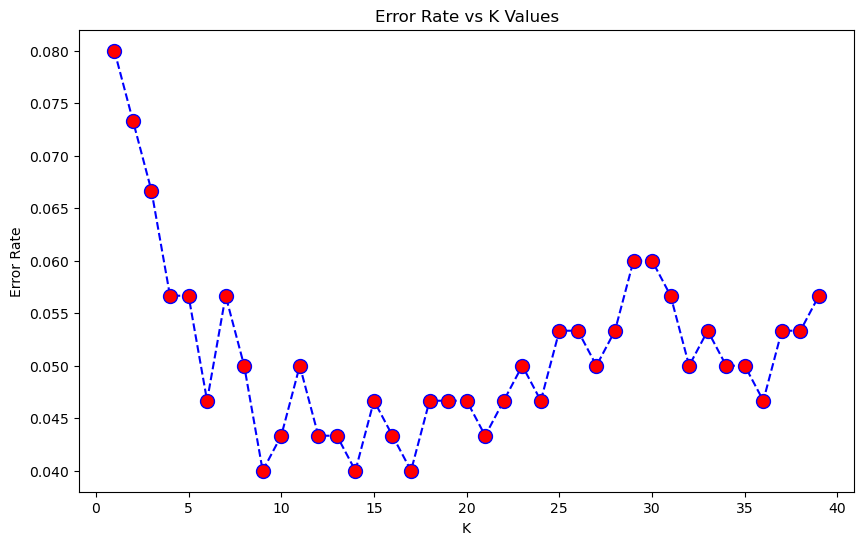

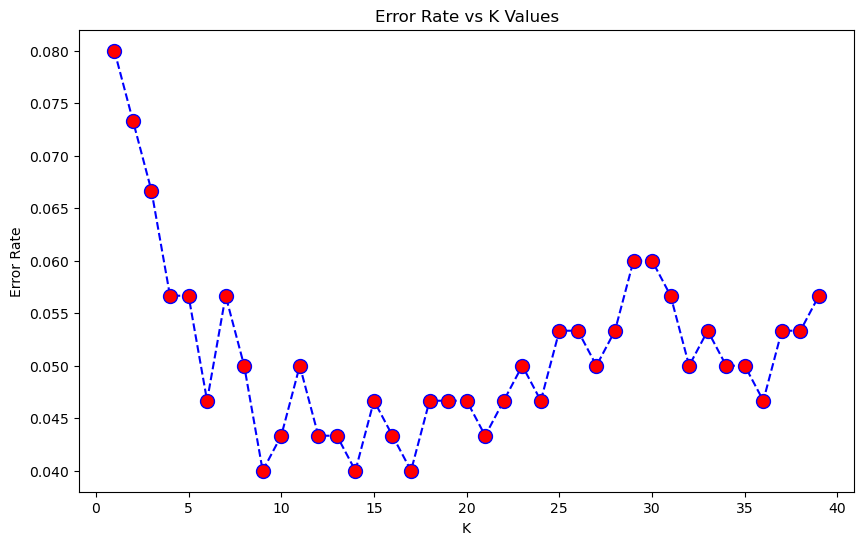

In [36]:
#plot a graph to visualize the error rate
plt.figure(figsize=(10,6))
plt.plot(
    range(1,40),
    error_rate,
    color = "blue",
    linestyle = "dashed",
    marker = "o",
    markerfacecolor = "red",
    markersize = 10
    )
plt.title("Error Rate vs K Values")
plt.xlabel("K")
plt.ylabel("Error Rate")

plt.show()

In [48]:
#get the index with the lowest errors at a give k value
lowest_error_at_k = error_rate.index(min(error_rate)) +1 
highest_error_at_k = error_rate.index(max(error_rate)) +1
print(lowest_error_at_k)
print(highest_error_at_k)

9
1


In [50]:
#Reperform the same test with K = 8 and compare it with k = 1
knn_worst = KNeighborsClassifier(n_neighbors= highest_error_at_k ) 
knn_best = KNeighborsClassifier(n_neighbors= lowest_error_at_k ) 


knn_worst.fit(X_train,y_train)
knn_best.fit(X_train,y_train)

pred_worst = knn_worst.predict(x_test)
pred_best = knn_best.predict(x_test)

In [51]:
# Get the comparitive Scores of the best and worst performing k values 
print("Comparision  Confusion Matrix: ")
print("at K = 1")
print(confusion_matrix(y_test,pred_worst))
print("at K = 8")
print(confusion_matrix(y_test,pred_best))


print("Comparision  Classification Report: ")
print("at K = 1")
print(classification_report(y_test,pred_worst))
print("at K = 8")
print(classification_report(y_test,pred_best))


Comparision  Confusion Matrix: 
at K = 1
[[144  12]
 [ 12 132]]
at K = 8
[[147   9]
 [  3 141]]
Comparision  Classification Report: 
at K = 1
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       156
           1       0.92      0.92      0.92       144

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300

at K = 8
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       156
           1       0.94      0.98      0.96       144

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

